# Conflict Graph Topology Analysis

This notebook analyzes the topology of conflict graphs generated from synthetic data. 
Understanding the graph structure (e.g., degree distribution, connected components) helps in optimizing the repair algorithm (Weighted Vertex Cover).

## Key Questions:
1. **Is the graph sparse or dense?**
2. **Are there many small components or one giant component?**
3. **What is the degree distribution?** (Power-law vs. Poisson)
4. **How do hubs impact the conflict structure?**

In [9]:
import os
import sys
import pandas as pd
import numpy as np
import igraph as ig
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# Add project root to path if needed
sys.path.append(os.path.abspath('..'))

GRAPH_DIR = Path('../outputs/graphs')
STATS_CACHE = Path('../outputs/graph_topology_summary.csv')
sns.set_theme(style='whitegrid')

## 1. Analysis Functions

Loading large GraphML files (up to 2GB) is slow because it involves XML parsing. 
We extract key topological statistics and cache them in a CSV to avoid repeated loading.

In [10]:
def analyze_graph_enhanced(file_path):
    print(f"Processing {file_path.name}...")
    # Note: ig.Graph.Read_GraphML is the bottleneck for large files
    g = ig.Graph.Read_GraphML(str(file_path))
    
    degrees = np.array(g.degree())
    active = degrees[degrees > 0]
    comps = g.connected_components()
    comp_sizes = comps.sizes()
    
    # Parse metadata from filename
    # e.g., graph_adult_aim_eps0.1_graph.graphml
    match_eps = re.search(r"eps([\d.]+)", file_path.name)
    eps = float(match_eps.group(1)) if match_eps else 1.0
    
    parts = file_path.name.split('_')
    dataset = parts[1] if len(parts) > 1 else "unknown"
    algorithm = parts[2] if len(parts) > 2 else "unknown"
    
    # Hub Analysis: Top 1% of active nodes
    n_active = len(active)
    top_1_pct_count = max(1, int(n_active * 0.01))
    top_degrees = sorted(active, reverse=True)[:top_1_pct_count]
    hub_coverage = sum(top_degrees) / (2 * g.ecount()) if g.ecount() > 0 else 0
    
    stats = {
        "name": file_path.name,
        "dataset": dataset,
        "algorithm": algorithm,
        "eps": eps,
        "n_vertices": g.vcount(),
        "n_edges": g.ecount(),
        "n_active": n_active,
        "max_degree": int(np.max(degrees)) if len(degrees) > 0 else 0,
        "mean_degree_active": float(np.mean(active)) if len(active) > 0 else 0,
        "median_degree_active": float(np.median(active)) if len(active) > 0 else 0,
        "n_components": len(comps),
        "giant_comp_size": int(np.max(comp_sizes)) if len(comp_sizes) > 0 else 0,
        "hub_coverage_top_1pct": float(hub_coverage)
    }
    return stats

## 2. Load or Compute Statistics

Check for cached CSV first to save time.

In [11]:
if STATS_CACHE.exists():
    print(f"Loading statistics from cache: {STATS_CACHE}")
    df_results = pd.read_csv(STATS_CACHE)
else:
    print("Cache not found. Starting analysis of GraphML files...")
    graph_files = sorted(list(GRAPH_DIR.glob('*_graph.graphml')))
    all_results = []
    for f in graph_files:
        try:
            res = analyze_graph_enhanced(f)
            all_results.append(res)
        except Exception as e:
            print(f"Error processing {f.name}: {e}")
    
    df_results = pd.DataFrame(all_results)
    df_results.to_csv(STATS_CACHE, index=False)
    print(f"Analysis complete. Statistics saved to {STATS_CACHE}")

df_results.head()

Cache not found. Starting analysis of GraphML files...
Processing graph_adult_aim_eps0.001_graph.graphml...
Error processing graph_adult_aim_eps0.001_graph.graphml: Error at src/io/graphml.c:1585: Line 875265696: StartTag: invalid element name. -- Parse error
Processing graph_adult_aim_eps0.1_graph.graphml...
Processing graph_adult_aim_eps0.5_graph.graphml...
Processing graph_adult_aim_eps0.7_graph.graphml...
Processing graph_adult_aim_eps1.0_graph.graphml...
Processing graph_adult_mst_eps0.1_graph.graphml...
Processing graph_adult_mst_eps0.5_graph.graphml...
Processing graph_adult_mst_eps1.0_graph.graphml...
Processing graph_census_aim_eps0.1_graph.graphml...
Processing graph_census_aim_eps0.5_graph.graphml...
Processing graph_census_aim_eps1.0_graph.graphml...
Processing graph_census_mst_eps0.1_graph.graphml...
Processing graph_census_mst_eps0.5_graph.graphml...
Processing graph_census_mst_eps0.8_graph.graphml...
Processing graph_census_mst_eps1.0_graph.graphml...
Processing graph_co

,name,dataset,algorithm,eps,n_vertices,n_edges,n_active,max_degree,mean_degree_active,median_degree_active,n_components,giant_comp_size,hub_coverage_top_1pct
0,graph_adult_aim_eps0.1_graph.graphml,adult,aim,0.1,48842,33780982,48842,47862,1383.275951,719.0,1,48842,0.229997
1,graph_adult_aim_eps0.5_graph.graphml,adult,aim,0.5,48842,29735953,48842,48465,1217.638631,646.0,1,48842,0.307807
2,graph_adult_aim_eps0.7_graph.graphml,adult,aim,0.7,48842,14159902,48842,48517,579.824823,289.0,1,48842,0.480680
3,graph_adult_aim_eps1.0_graph.graphml,adult,aim,1.0,48842,25218457,48842,48396,1032.654560,481.0,1,48842,0.345354
4,graph_adult_mst_eps0.1_graph.graphml,adult,mst,0.1,48842,45271152,48842,48286,1853.779616,1052.0,1,48842,0.140098


## 3. Visualization of Epsilon Trends

We plot topological metrics against Epsilon, splitting by dataset (color) and generation algorithm (line style).

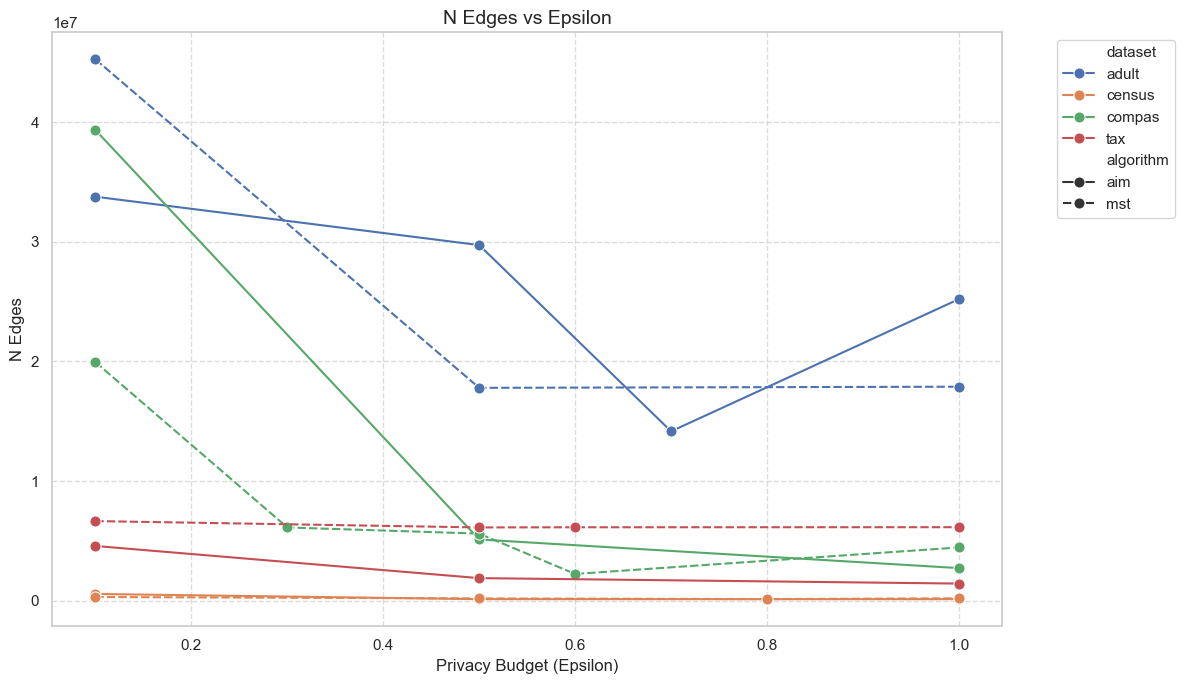

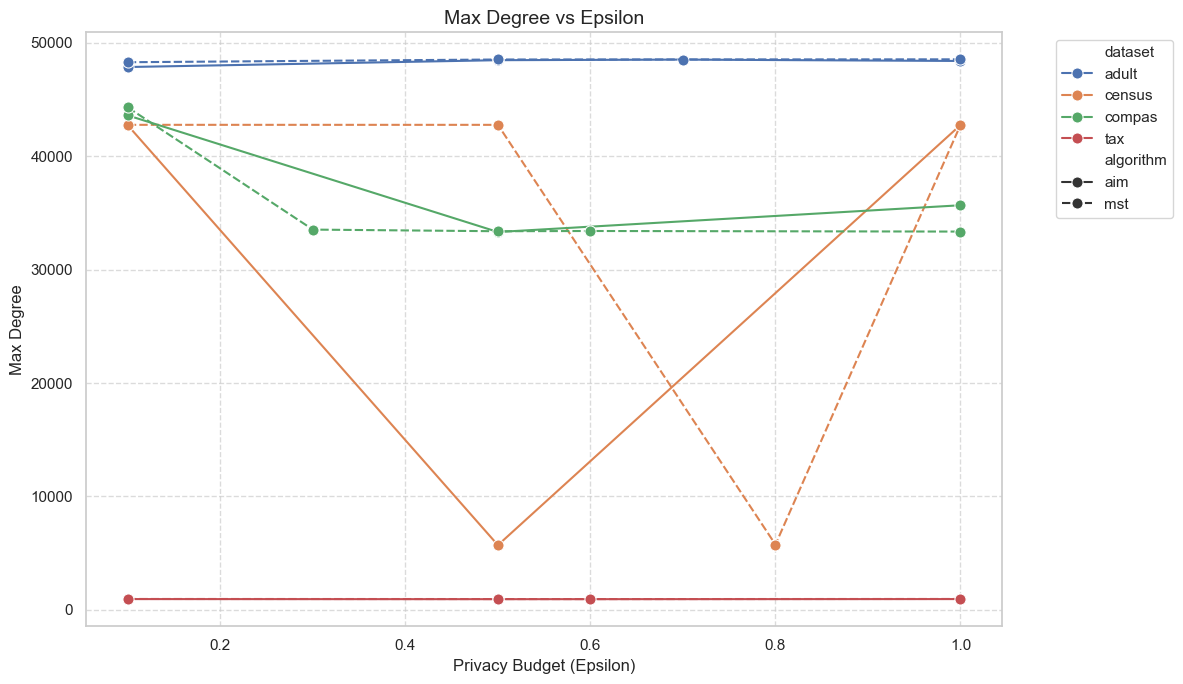

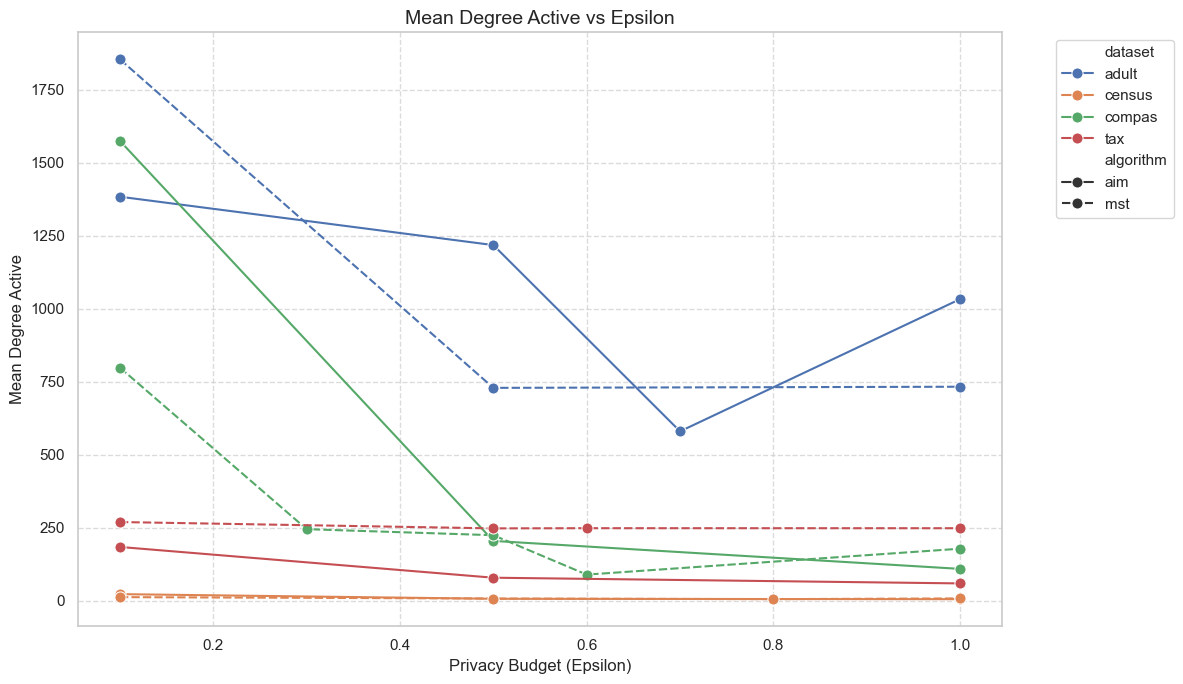

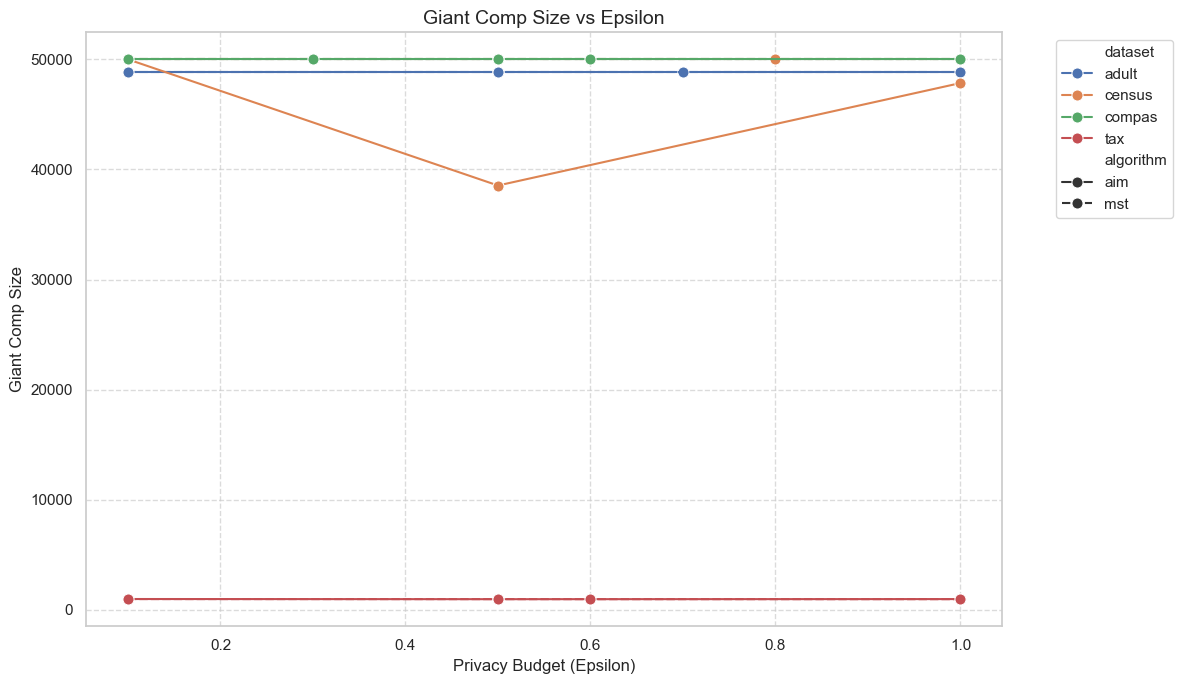

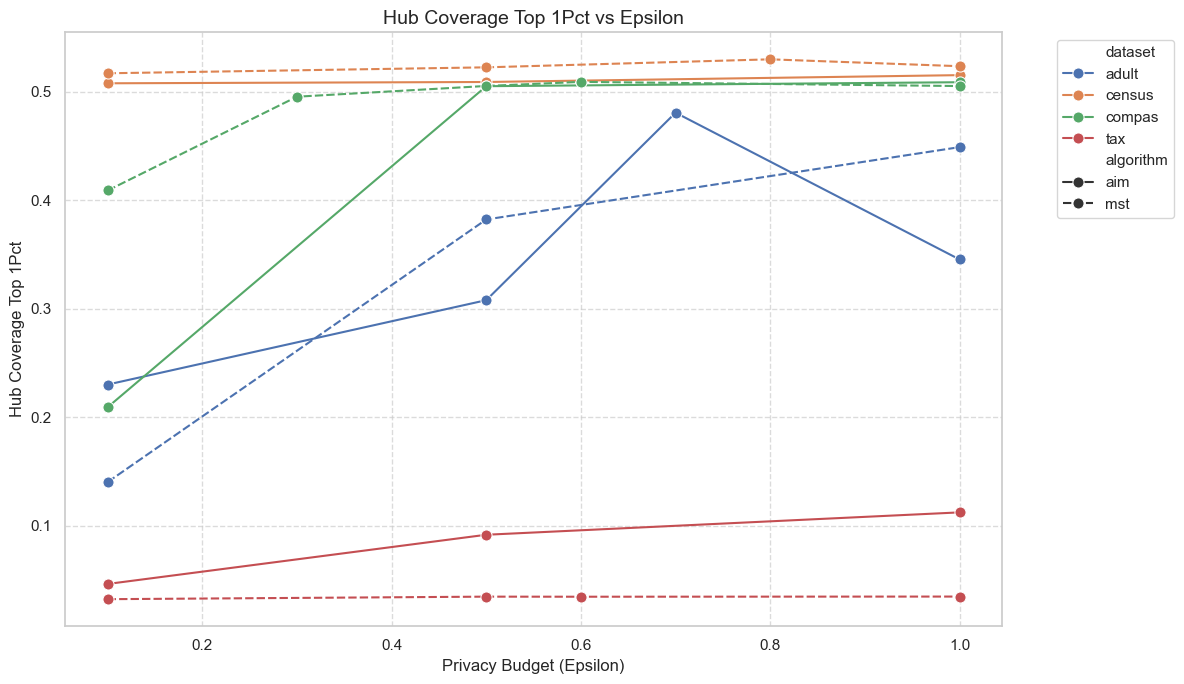

In [12]:
def plot_vs_eps(df, metric, title):
    plt.figure(figsize=(12, 7))
    # Split by dataset (hue) and algorithm (style)
    sns.lineplot(data=df, x="eps", y=metric, hue="dataset", style="algorithm", marker="o", markersize=8)
    plt.title(title, fontsize=14)
    plt.xlabel("Privacy Budget (Epsilon)", fontsize=12)
    plt.ylabel(metric.replace('_', ' ').title(), fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

metrics = ["n_edges", "max_degree", "mean_degree_active", "giant_comp_size", "hub_coverage_top_1pct"]
for m in metrics:
    plot_vs_eps(df_results, m, f"{m.replace('_', ' ').title()} vs Epsilon")